In [1]:
import math
import copy
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

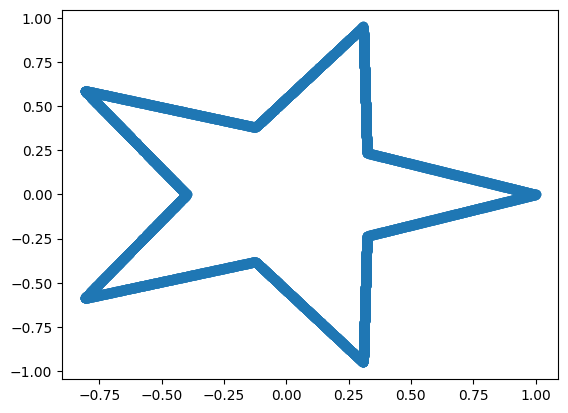

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [3]:
class VPConfig:
    def __init__(self, schedule="cosine", weighting="snr", epochs=1500):
        self.schedule = schedule
        self.weighting = weighting
        self.epochs = epochs
        self.beta_min = 0.1
        self.beta_max = 10.0
        self.cosine_s = 0.008
        self.lr = 1e-3
        self.batch_size = 512
        self.hidden_dim = 256
        self.time_dim = 64
        self.num_timesteps = 1000
        self.data_samples = 5000
        self.ema_decay = 0.999
        self.weight_clip = 20.0

In [4]:
def get_vp_terms(t, config):
    if config.schedule == "linear":
        beta = config.beta_min + t * (config.beta_max - config.beta_min)
        int_beta = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * (t ** 2)
        alpha_bar = torch.exp(-int_beta)
    elif config.schedule == "cosine":
        s = config.cosine_s
        theta = (t + s) / (1.0 + s) * (math.pi / 2.0)
        theta0 = (s / (1.0 + s)) * (math.pi / 2.0)
        alpha_bar = (torch.cos(theta).clamp_min(1e-5) / math.cos(theta0)) ** 2
        beta = (math.pi / (1.0 + s)) * torch.tan(theta)
        beta = beta.clamp(min=1e-5, max=config.beta_max)
    else:
        raise ValueError("Unknown schedule")

    alpha = torch.sqrt(alpha_bar.clamp_min(1e-5))
    sigma = torch.sqrt((1.0 - alpha_bar).clamp_min(1e-5))
    return beta, alpha, sigma

In [5]:
def get_loss_weight(t, alpha, sigma, beta, config):
    eps = 1e-8
    if config.weighting == "const":
        w = torch.ones_like(t)
    elif config.weighting == "sigma2":
        w = sigma ** 2
    elif config.weighting == "snr":
        w = (alpha ** 2) / (sigma ** 2 + eps)
    elif config.weighting == "beta":
        w = beta
    else:
        raise ValueError("Unknown weighting")

    w = torch.clamp(w, max=config.weight_clip)
    w = w / (w.mean().detach() + eps)
    return w

In [6]:
class VPScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.time_dim = config.time_dim

        self.time_mlp = nn.Sequential(
            nn.Linear(config.time_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def get_time_embedding(self, t):
        half = self.time_dim // 2
        freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device, dtype=t.dtype) / max(half - 1, 1))
        args = t * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(self.get_time_embedding(t))
        x_input = torch.cat([x, t_emb], dim=1)
        return self.net(x_input)

In [7]:
def update_ema(ema_model, model, decay):
    with torch.no_grad():
        for ema_p, p in zip(ema_model.parameters(), model.parameters()):
            ema_p.data.mul_(decay).add_(p.data, alpha=1.0 - decay)

class VPTrainer:
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = VPScoreModel(config).to(self.device)
        self.ema_model = copy.deepcopy(self.model).to(self.device)
        for p in self.ema_model.parameters():
            p.requires_grad = False

        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device) * (1.0 - 1e-3) + 1e-3
            beta, alpha, sigma = get_vp_terms(t, self.config)

            noise = torch.randn_like(batch)
            x_t = alpha * batch + sigma * noise

            pred_noise = self.model(x_t, t)

            w = get_loss_weight(t, alpha, sigma, beta, self.config)

            per_sample_loss = ((pred_noise - noise) ** 2).mean(dim=1)
            loss = (w.squeeze(1) * per_sample_loss).mean()

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            update_ema(self.ema_model, self.model, self.config.ema_decay)
            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        hist = []
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            hist.append(loss)
            if n % 300 == 0:
                print(f'[{self.config.schedule} | {self.config.weighting}] Epoch {n:4d} | Loss: {loss:.4f}')
        return hist

In [8]:
def sample_vp_sde(model, config, num_samples=1000):
    device = next(model.parameters()).device
    model.eval()

    x = torch.randn(num_samples, 2, device=device)
    dt = 1.0 / config.num_timesteps

    with torch.no_grad():
        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-3)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta, _, sigma = get_vp_terms(t_tensor, config)
            pred_noise = model(x, t_tensor)

            score = -pred_noise / sigma.clamp_min(1e-4)

            drift = (0.5 * beta * x + beta * score) * dt
            diffusion = torch.sqrt(beta * dt) * torch.randn_like(x)

            if i == config.num_timesteps - 1:
                diffusion = torch.zeros_like(x)

            x = x + drift + diffusion

    return x.cpu().numpy()

--- Сравнение расписаний: Linear vs Cosine ---
Обучение расписания: linear
[linear | const] Epoch    0 | Loss: 0.9001
[linear | const] Epoch  300 | Loss: 0.2459
[linear | const] Epoch  600 | Loss: 0.2373
[linear | const] Epoch  900 | Loss: 0.2341
[linear | const] Epoch 1200 | Loss: 0.2167
Обучение расписания: cosine
[cosine | const] Epoch    0 | Loss: 0.9228
[cosine | const] Epoch  300 | Loss: 0.3377
[cosine | const] Epoch  600 | Loss: 0.3309
[cosine | const] Epoch  900 | Loss: 0.2865
[cosine | const] Epoch 1200 | Loss: 0.2871


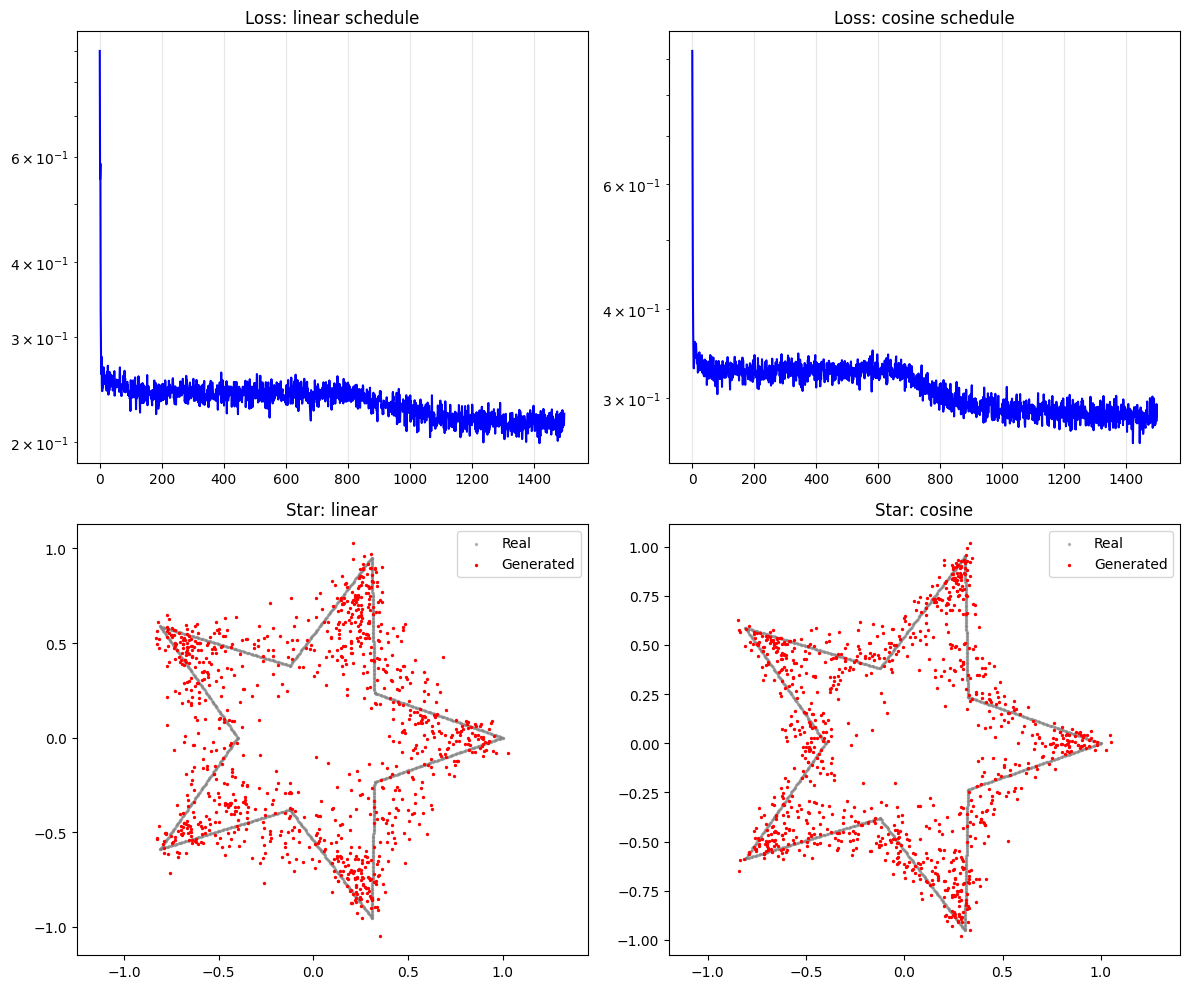


--- Сравнение перезвешивания лосса (на Cosine schedule) ---
Обучение веса: const
[cosine | const] Epoch    0 | Loss: 0.9013
[cosine | const] Epoch  300 | Loss: 0.3158
[cosine | const] Epoch  600 | Loss: 0.3169
[cosine | const] Epoch  900 | Loss: 0.2792
[cosine | const] Epoch 1200 | Loss: 0.2798
Обучение веса: snr
[cosine | snr] Epoch    0 | Loss: 0.9678
[cosine | snr] Epoch  300 | Loss: 0.6809
[cosine | snr] Epoch  600 | Loss: 0.6344
[cosine | snr] Epoch  900 | Loss: 0.6323
[cosine | snr] Epoch 1200 | Loss: 0.6087
Обучение веса: beta
[cosine | beta] Epoch    0 | Loss: 0.9100
[cosine | beta] Epoch  300 | Loss: 0.1080
[cosine | beta] Epoch  600 | Loss: 0.1036
[cosine | beta] Epoch  900 | Loss: 0.1059
[cosine | beta] Epoch 1200 | Loss: 0.1042
Обучение веса: sigma2
[cosine | sigma2] Epoch    0 | Loss: 0.8973
[cosine | sigma2] Epoch  300 | Loss: 0.1148
[cosine | sigma2] Epoch  600 | Loss: 0.1117
[cosine | sigma2] Epoch  900 | Loss: 0.1079
[cosine | sigma2] Epoch 1200 | Loss: 0.1123


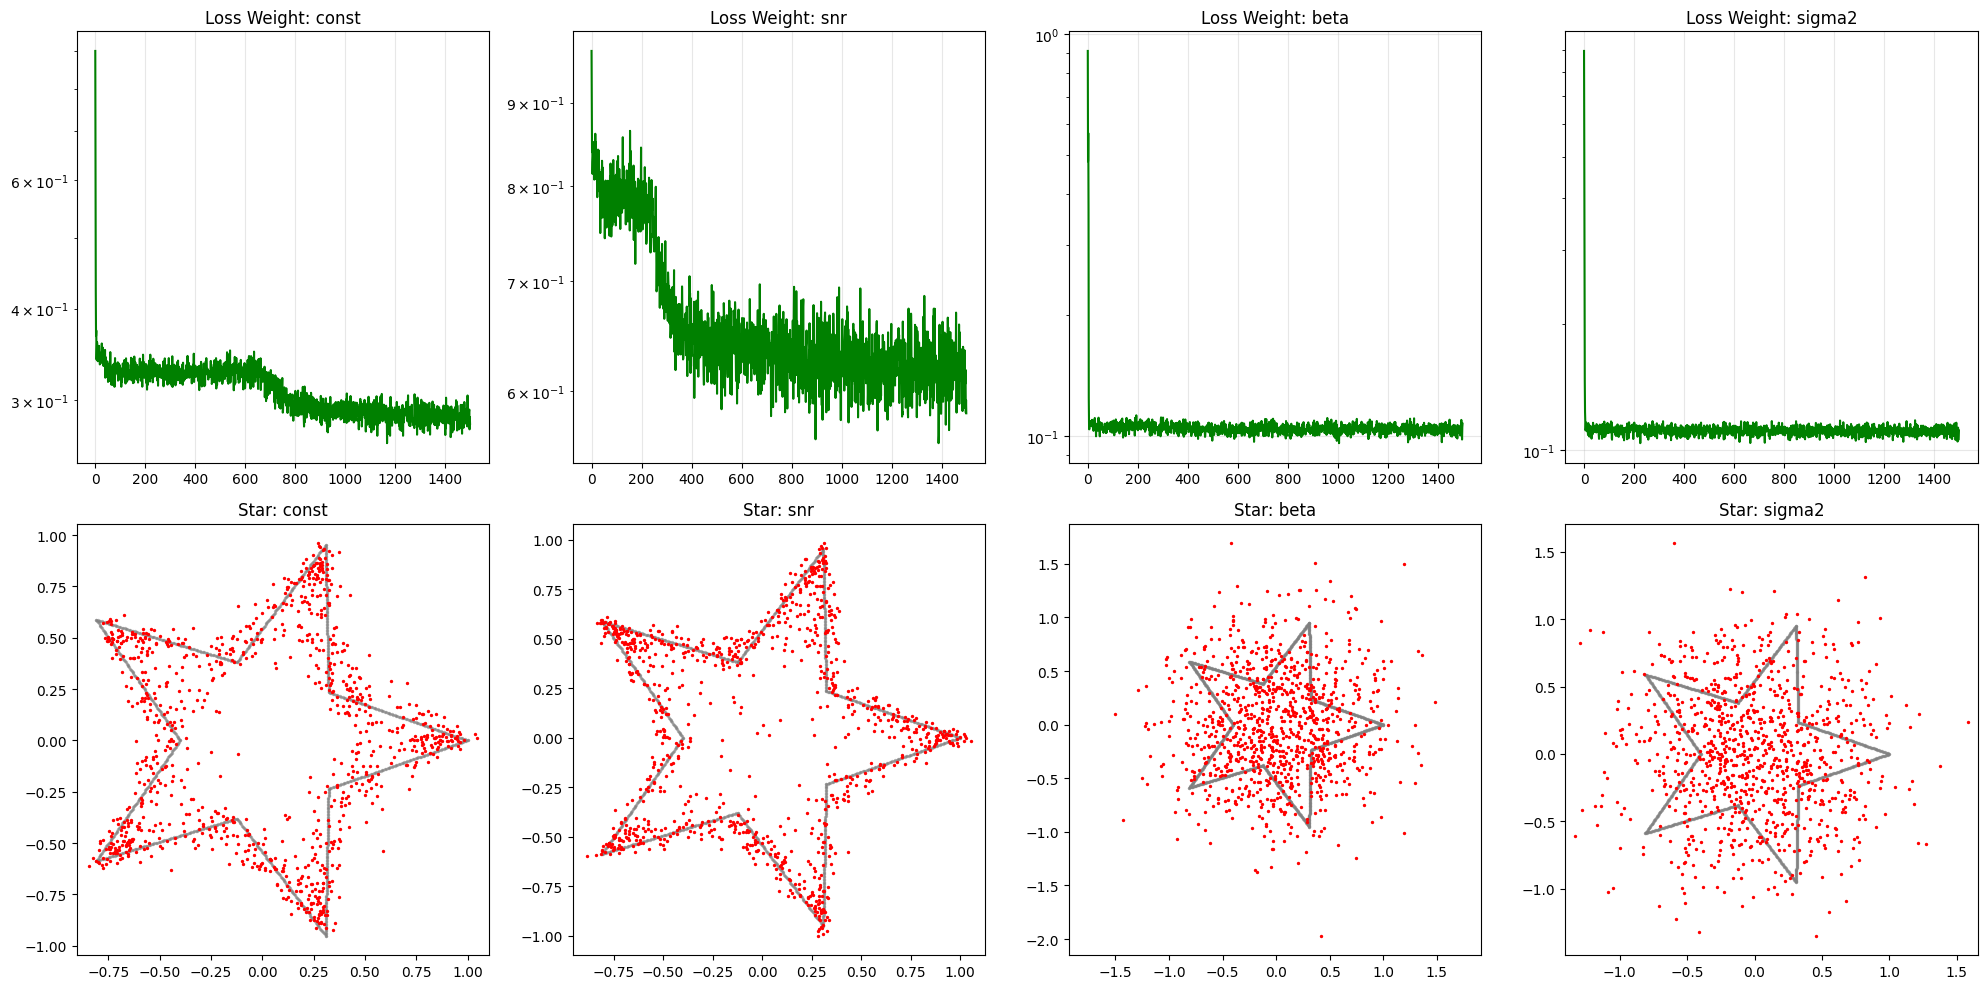

In [9]:
def run_all_experiments():
    real_data = generate_star(n_samples=1000)

    print("--- Сравнение расписаний: Linear vs Cosine ---")
    schedules = ["linear", "cosine"]
    sched_results = []

    for sch in schedules:
        print(f"Обучение расписания: {sch}")
        cfg = VPConfig(schedule=sch, weighting="const", epochs=1500)
        trainer = VPTrainer(cfg)
        hist = trainer.run()
        samples = sample_vp_sde(trainer.ema_model, cfg, 1000)
        sched_results.append((sch, samples, hist))

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for i, (sch, samples, hist) in enumerate(sched_results):
        axes[0, i].plot(hist, color='blue')
        axes[0, i].set_title(f"Loss: {sch} schedule")
        axes[0, i].set_yscale('log')
        axes[0, i].grid(True, alpha=0.3)

        axes[1, i].scatter(real_data[:, 0], real_data[:, 1], s=2, alpha=0.5, label="Real", color='gray')
        axes[1, i].scatter(samples[:, 0], samples[:, 1], s=2, label="Generated", color='red')
        axes[1, i].set_title(f"Star: {sch}")
        axes[1, i].axis("equal")
        axes[1, i].legend()
    plt.tight_layout()
    plt.show()

    print("\n--- Сравнение перезвешивания лосса (на Cosine schedule) ---")
    weightings = ["const", "snr", "beta", "sigma2"]
    weight_results = []

    for w in weightings:
        print(f"Обучение веса: {w}")
        cfg = VPConfig(schedule="cosine", weighting=w, epochs=1500)
        trainer = VPTrainer(cfg)
        hist = trainer.run()
        samples = sample_vp_sde(trainer.ema_model, cfg, 1000)
        weight_results.append((w, samples, hist))

    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    for i, (w, samples, hist) in enumerate(weight_results):
        axes[0, i].plot(hist, color='green')
        axes[0, i].set_title(f"Loss Weight: {w}")
        axes[0, i].set_yscale('log')
        axes[0, i].grid(True, alpha=0.3)

        axes[1, i].scatter(real_data[:, 0], real_data[:, 1], s=2, alpha=0.5, label="Real", color='gray')
        axes[1, i].scatter(samples[:, 0], samples[:, 1], s=2, label="Generated", color='red')
        axes[1, i].set_title(f"Star: {w}")
        axes[1, i].axis("equal")
    plt.tight_layout()
    plt.show()

run_all_experiments()

Linear - шум добавляется слишком быстро в начале, модель плохо улавливает мелкие детали, контуры более размытые

Cosine - добавляет шум плавно, даёт модели больше времени, чтобы выучить четкие контуры. Звезда получается чёткой.

SNR - даёт лучший результат. Заставляет модель фокусироваться на тех моментах, когда звезда еще узнаваема под шумом. Грани получаются более чёткими. На 5000 эпохах в прошлой модели у меня прям четкая звезда получалась без точек в середине, но на звездах выше тоже видно, что именно внешние контуры лучше чем у const

Const - звезда видна, но есть много лишних точек вокруг. Модель слишком много сил тратит на угадывание случайного шума.

Beta и Sigma2 -Графики лосса упали в ноль почти сразу, но вместо звезды просто много хаотичных точнк. Это произошло потому, что математические веса этих функций подавили полезные сигналы при обучении.


Итого - Самая эффективная связка для VP-SDE - Cosine + SNR.